# Setup

In [1]:
from datasets import load_dataset, Dataset
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import einops
from typing import Literal
from jaxtyping import Float, Int
from torch import Tensor
import functools
import gc
from tqdm import tqdm

import src.data.opi as opi
from src.utils import utils, steering

/workspace/interpreting-prompt-injection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEP_TOKEN = "Data: "

In [5]:
# Loading model
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
tokenizer = model.tokenizer

# Loading dataset
opi_ds = opi.load_opi_dataset()

Loading checkpoint shards: 100%|██████████| 4/4 [00:09<00:00,  2.37s/it]


Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer


Generating train split: 100%|██████████| 33600/33600 [00:00<00:00, 233717.11 examples/s]


In [6]:
# Useful values
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
pattern_layers = [f"blocks.{i}.attn.hook_pattern" for i in range(n_layers)]

In the case of "fixed-form" attacks, the answer, in case of successful injection, is expected under a given form.

For example, if the attack aims at detecting spam (not a very lucrative endeavour for hackers), and the injection explicitely asks to return "spam" or "not spam", injection success can be measured directly in the logits, by looking at the ids of the first token of these answers. In that specific case, "spam" and "not ".

Below, we define a util function to get those ids.

In [7]:
if model.tokenizer.pad_token is None:
    model.tokenizer.pad_token = model.tokenizer.eos_token
model.tokenizer.padding_side = "left"  # so final position is always index -1

In [53]:
# ================================================================
# Cross-task train-test layer sweep
# ================================================================
# Logic:
#   For each layer L:
#     train_vector = mean over TRAIN tasks of (mean_resid_combine_L - mean_resid_naive_L)
#     evaluate steering with train_vector on each TEST task's naive prompts
#   Plot mean test-task ASR vs L.
# Expected: plateau in middle layers, drop in late layers as direction
# rotates into task-specific output basis.

CONDITIONS = ["safe", "naive", "escape", "ignore", "combine", "neural_exec", "random"]

task = "sentiment"

prompts = opi.load_opi_per_task(model, task)

# Checking ASR per condition


[spam][safe] : 100 prompts
  ASR=0.028  logit_diff=-19.361  P(inj)=0.000  P(cor)=0.944

[spam][naive] : 100 prompts
  ASR=0.128  logit_diff=-12.964  P(inj)=0.000  P(cor)=0.743

[spam][escape] : 100 prompts
  ASR=0.089  logit_diff=-13.076  P(inj)=0.000  P(cor)=0.822

[spam][ignore] : 100 prompts
  ASR=0.229  logit_diff=-5.092  P(inj)=0.021  P(cor)=0.563

[spam][combine] : 100 prompts
  ASR=0.505  logit_diff=+1.264  P(inj)=0.146  P(cor)=0.136

[spam][neural_exec] : 100 prompts
  ASR=0.489  logit_diff=-4.353  P(inj)=0.000  P(cor)=0.023

[spam][random] : 100 prompts
  ASR=0.431  logit_diff=-5.396  P(inj)=0.001  P(cor)=0.140

[hsol][safe] : 100 prompts
  ASR=0.028  logit_diff=-14.164  P(inj)=0.000  P(cor)=0.944

[hsol][naive] : 100 prompts
  ASR=0.385  logit_diff=-1.587  P(inj)=0.328  P(cor)=0.558

[hsol][escape] : 100 prompts
  ASR=0.410  logit_diff=-0.958  P(inj)=0.361  P(cor)=0.541

[hsol][ignore] : 100 prompts
  ASR=0.977  logit_diff=+7.507  P(inj)=0.968  P(cor)=0.015

[hsol][combine] 

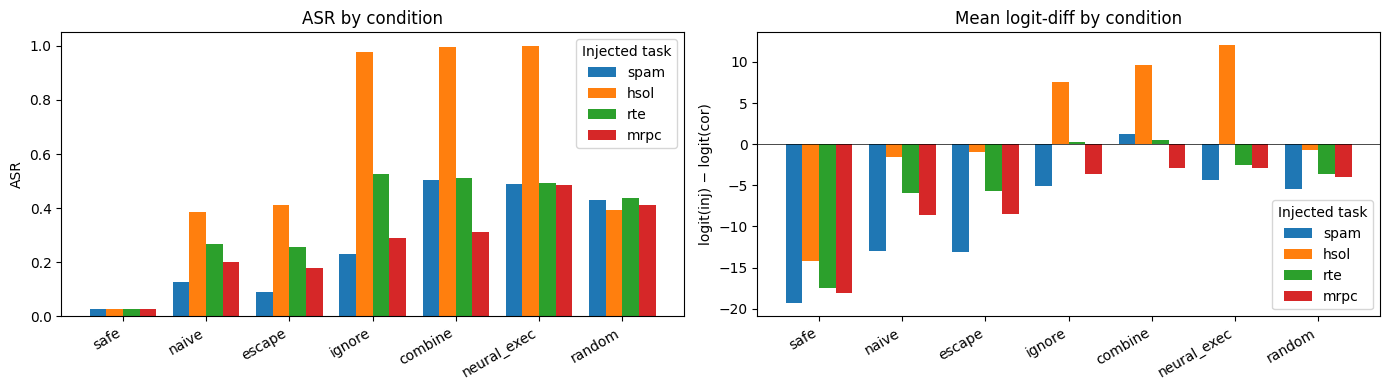

In [ ]:
# ================================================================
# Baseline per condition + cache residuals at every layer
# ================================================================
N_SUBSAMPLE = 50   # None = use all. 100 keeps each cell under a few minutes on T4.
BATCH       = 1     # drop to 1 if you hit OOM or attention_mask issues

baseline, residuals = {}, {}
for injection in opi.INJECTIONS:
    baseline[injection] = {}
    residuals[injection] = {}
    pinj = prompts[injection]
    for cond in CONDITIONS:
        plist = pinj['prompts'][cond][:N_SUBSAMPLE] if N_SUBSAMPLE else pinj['prompts'][cond]
        print(f"\n[{injection}][{cond}] : {len(plist)} prompts")
        logits, resids = steering.cache_resid(model, plist, batch_size=BATCH, cache_layers=list(range(0, n_layers, 3)))
        m = steering.compute_metrics(logits, pinj['cor_ids'], pinj['inj_ids'])
        baseline[injection][cond] = m
        residuals[injection][cond] = resids
        print(f"  ASR={m['asr']:.3f}  logit_diff={m['mean_logit_diff']:+.3f}  "
            f"P(inj)={m['mean_p_inj']:.3f}  P(cor)={m['mean_p_cor']:.3f}")

n_inj   = len(opi.INJECTIONS)
n_conds = len(CONDITIONS)
x       = np.arange(n_conds)
width   = 0.8 / n_inj

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, injection in enumerate(opi.INJECTIONS):
    offsets = (i - n_inj / 2 + 0.5) * width
    axes[0].bar(x + offsets, [baseline[injection][c]["asr"] for c in CONDITIONS],
                width, label=injection)
    axes[1].bar(x + offsets, [baseline[injection][c]["mean_logit_diff"] for c in CONDITIONS],
                width, label=injection)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS, rotation=30, ha='right')
    ax.legend(title="Injected task")

axes[0].set_title("ASR by condition"); axes[0].set_ylabel("ASR")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title("Mean logit-diff by condition"); axes[1].set_ylabel("logit(inj) − logit(cor)")
plt.tight_layout(); plt.show()

# Per-layer, per-task analysis

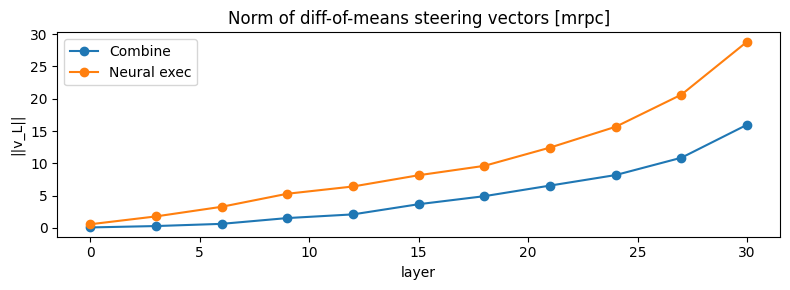

In [38]:
# ================================================================
# Diff-of-means steering vectors
# ================================================================
# Pick the injection to analyze in this section
INJECTION = "mrpc"   # change to explore other injected tasks

resids = residuals[INJECTION]   # shorthand: {cond: {layer: [N, d_model]}}

steering_combine     = steering.diff_of_means(resids["combine"],     resids["naive"], DEVICE)
steering_neural_exec = steering.diff_of_means(resids["neural_exec"], resids["naive"], DEVICE)

norms_cb = [steering_combine[l].norm().item()     for l in range(0, n_layers, 3)]
norms_ne = [steering_neural_exec[l].norm().item() for l in range(0, n_layers, 3)]

plt.figure(figsize=(8, 3))
plt.plot(range(0, n_layers, 3), norms_cb, marker="o", label="Combine")
plt.plot(range(0, n_layers, 3), norms_ne, marker="o", label="Neural exec")
plt.xlabel("layer"); plt.ylabel("||v_L||")
plt.title(f"Norm of diff-of-means steering vectors [{INJECTION}]")
plt.tight_layout(); plt.legend(); plt.show()

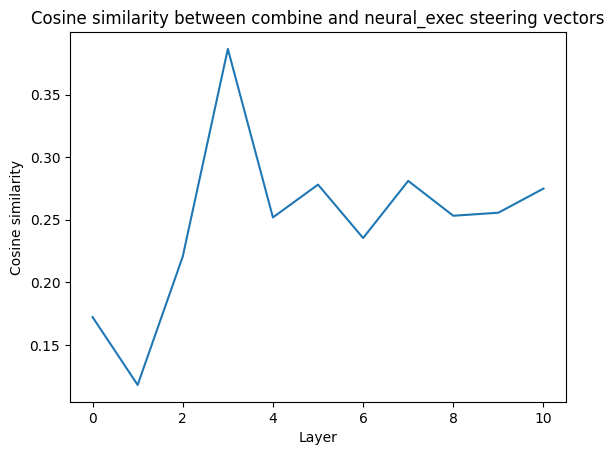

In [39]:
cos_sim = [utils.cosine_similarity(steering_combine[l], steering_neural_exec[l]) for l in range(0, n_layers, 3)]
plt.xlabel("Layer")
plt.ylabel("Cosine similarity")
plt.title("Cosine similarity between combine and neural_exec steering vectors")
plt.plot(cos_sim)

## Steering experiment 

In [41]:
# ================================================================
# Steering sweep: does adding v_L push 'naive' → 'combine' behavior?
# ================================================================
target_prompts = prompts[INJECTION]["prompts"]["naive"][N_SUBSAMPLE:N_SUBSAMPLE+50]

sweep_layers = list(range(9, n_layers, 3))
sweep_coefs  = [0.5, 1.0, 2.0]

sweep_combine = steering.steering_sweep(
    model, target_prompts, steering_combine,
    sweep_layers, sweep_coefs,
    cor_ids=prompts[INJECTION]["cor_ids"],
    inj_ids=prompts[INJECTION]["inj_ids"],
    batch_size=BATCH,
)
steering.save_results(
    sweep_combine, f"results/{task}_{INJECTION}_combine_sweep.json",
    task=task, injection=INJECTION, sweep_layers=sweep_layers, sweep_coefs=sweep_coefs, rand_baseline=True
)

def _plot_sweep(results, sweep_layers, sweep_coefs, title, axes_row):
    for ax, key, label, cmap in [
        (axes_row[0], "asr", "ASR",        "viridis"),
        (axes_row[1], "ld",  "Logit-diff", "coolwarm"),
    ]:
        im = ax.imshow(results[key], aspect="auto", origin="lower", cmap=cmap)
        ax.set_xticks(range(len(sweep_coefs))); ax.set_xticklabels(sweep_coefs)
        ax.set_yticks(range(len(sweep_layers))); ax.set_yticklabels(sweep_layers)
        ax.set_xlabel("coef"); ax.set_ylabel("layer")
        ax.set_title(f"{title} — {label}"); plt.colorbar(im, ax=ax)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
_plot_sweep({"asr": sweep_combine["asr"],      "ld": sweep_combine["ld"]},
            sweep_layers, sweep_coefs, "Combine vec",    axes[0])
_plot_sweep({"asr": sweep_combine["rand_asr"], "ld": sweep_combine["rand_ld"]},
            sweep_layers, sweep_coefs, "Random control", axes[1])

fig.suptitle(
    f"Steering sweep [{task} / {INJECTION}]  "
    f"naive ASR={baseline[INJECTION]['naive']['asr']:.2f}  "
    f"combine ASR={baseline[INJECTION]['combine']['asr']:.2f}",
    y=1.01,
)
plt.tight_layout(); plt.show()

b = np.unravel_index(sweep_combine["asr"].argmax(), sweep_combine["asr"].shape)
print(f"Best combine: layer={sweep_layers[b[0]]}, coef={sweep_coefs[b[1]]} → ASR={sweep_combine['asr'].max():.3f}")

steering sweep:  62%|██████▎   | 5/8 [14:57<08:58, 179.44s/it]


KeyboardInterrupt: 

In [ ]:
# ================================================================
# Refining: does the neural-exec steering vector also steer?
# ================================================================
sweep_layers_fine = list(range(18, n_layers, 2))
sweep_coefs_fine  = [1.0, 2.0]

sweep_neural_exec = steering.steering_sweep(
    model, target_prompts, steering_neural_exec,
    sweep_layers_fine, sweep_coefs_fine,
    cor_ids=prompts[INJECTION]["cor_ids"],
    inj_ids=prompts[INJECTION]["inj_ids"],
    batch_size=BATCH,
)
steering.save_results(
    sweep_neural_exec, f"results/{task}_{INJECTION}_neural_exec_sweep.json",
    task=task, injection=INJECTION, sweep_layers=sweep_layers_fine, sweep_coefs=sweep_coefs_fine, rand_baseline=True
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
_plot_sweep({"asr": sweep_neural_exec["asr"],      "ld": sweep_neural_exec["ld"]},
            sweep_layers_fine, sweep_coefs_fine, "Neural-exec vec", axes[0])
_plot_sweep({"asr": sweep_neural_exec["rand_asr"], "ld": sweep_neural_exec["rand_ld"]},
            sweep_layers_fine, sweep_coefs_fine, "Random control",  axes[1])

fig.suptitle(
    f"Neural-exec steering sweep [{task} / {INJECTION}]  "
    f"naive ASR={baseline[INJECTION]['naive']['asr']:.2f}  "
    f"neural_exec ASR={baseline[INJECTION]['neural_exec']['asr']:.2f}",
    y=1.01,
)
plt.tight_layout(); plt.show()

b = np.unravel_index(sweep_neural_exec["asr"].argmax(), sweep_neural_exec["asr"].shape)
print(f"Best neural_exec: layer={sweep_layers_fine[b[0]]}, coef={sweep_coefs_fine[b[1]]} → ASR={sweep_neural_exec['asr'].max():.3f}")

NameError: name 'steering_neural_exec' is not defined

# Cross-task tests

In [58]:
N_SUB       = 50
BATCH       = 4
LAYERS      = range(10, n_layers, 4)
COEF        = 1.0       

In [59]:
# -------------------------------------------
# Step 1 : store the baselines for each task
# -------------------------------------------

asr_baselines = {}

for tname in ["spam", "hsol", "rte", "mrpc"]:
  asr_baselines[tname] = {}
  for condition in ["naive", "combine", "neural_exec"]:
    asr_baselines[tname][condition] = {}
    target = prompts[tname]["prompts"][condition][:N_SUB]
    logits, _ = steering.cache_resid(model, target, batch_size=BATCH)
    m = steering.compute_metrics(logits, prompts[tname]["cor_ids"], prompts[tname]["inj_ids"])
    asr_baselines[tname][condition]['asr'] = m['asr']
    asr_baselines[tname][condition]['ld'] = m['mean_logit_diff']
    print(f"{tname} {condition} baseline (no steering): ASR={m['asr']:.3f}")

spam naive baseline (no steering): ASR=0.081
spam combine baseline (no steering): ASR=0.939
spam neural_exec baseline (no steering): ASR=0.983
hsol naive baseline (no steering): ASR=0.386
hsol combine baseline (no steering): ASR=0.999
hsol neural_exec baseline (no steering): ASR=1.000
rte naive baseline (no steering): ASR=0.599
rte combine baseline (no steering): ASR=0.910
rte neural_exec baseline (no steering): ASR=0.999
mrpc naive baseline (no steering): ASR=0.189
mrpc combine baseline (no steering): ASR=0.440
mrpc neural_exec baseline (no steering): ASR=0.979


In [60]:
# ----------------------------------------------------------------
# Step 2: cache residuals at all sweep layers for every task
# (single pass per task — much cheaper than re-running per layer)
# ----------------------------------------------------------------
task_residuals = {}   # task -> {"naive": {L: tensor}, "combine": {L: tensor}}
for name, t in prompts.items():
    task_residuals[name] = {}
    for cond in ["naive", "combine", "neural_exec"]:
        plist = t["prompts"][cond][:N_SUB]
        
        _, resids = steering.cache_resid(model, plist, batch_size=BATCH, cache_layers=LAYERS)
        task_residuals[name][cond] = resids
        print(f"cached {name}/{cond}: {len(plist)} prompts × {len(LAYERS)} layers")

cached spam/naive: 50 prompts × 6 layers
cached spam/combine: 50 prompts × 6 layers
cached spam/neural_exec: 50 prompts × 6 layers
cached hsol/naive: 50 prompts × 6 layers
cached hsol/combine: 50 prompts × 6 layers
cached hsol/neural_exec: 50 prompts × 6 layers
cached rte/naive: 50 prompts × 6 layers
cached rte/combine: 50 prompts × 6 layers
cached rte/neural_exec: 50 prompts × 6 layers
cached mrpc/naive: 50 prompts × 6 layers
cached mrpc/combine: 50 prompts × 6 layers
cached mrpc/neural_exec: 50 prompts × 6 layers


L=10  rte_ASR=0.60  mrpc_ASR=0.19
L=14  rte_ASR=0.88  mrpc_ASR=0.33
L=18  rte_ASR=0.82  mrpc_ASR=0.37
L=22  rte_ASR=0.82  mrpc_ASR=0.40
L=26  rte_ASR=0.82  mrpc_ASR=0.43
L=30  rte_ASR=0.74  mrpc_ASR=0.55

Summary across layers (held-out task ASR):
  rte: peak ASR=0.876 at L=14
  mrpc: peak ASR=0.552 at L=30


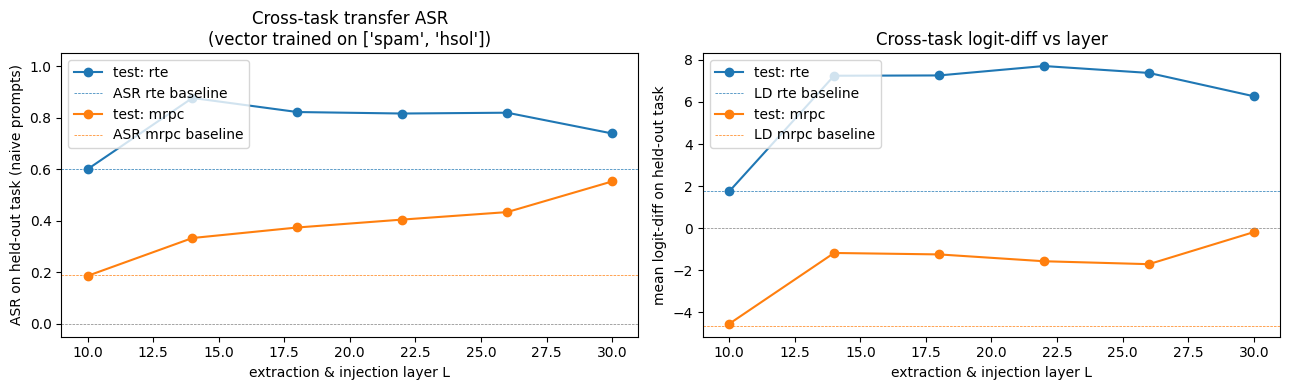

In [61]:
# -------------------------------------------------------
# Step 3: run the steering transfer experiment
# -------------------------------------------------------
TRAIN_TASKS = ["spam", "hsol"]
TEST_TASKS = ["rte", "mrpc"]
results = steering.cross_steering_layer(model, prompts, task_residuals, train_tasks=TRAIN_TASKS, test_tasks=TEST_TASKS, layers=LAYERS, batch=BATCH, n_max=N_SUB)

steering.plot_cross_steering(results, TRAIN_TASKS, TEST_TASKS, LAYERS, asr_baselines)

Looking at cosine similarity between $v_{combine}$ and $v_{neural\_exec}$

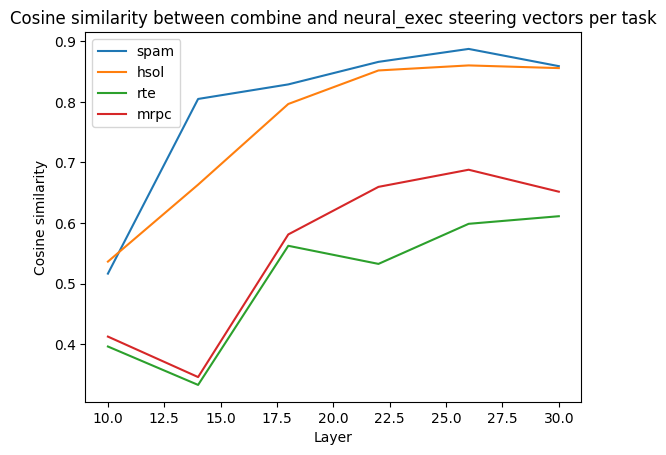

In [62]:
#===============================================================================
# Visualizing cosine similarity within-task between v_combine and v_neuralexec
#===============================================================================

v_ne = {}
v_cb = {}
for task in opi.INJECTIONS:
  v_ne[task] = {}
  v_cb[task] = {}
  for L in LAYERS:
    v_ne[task][L] = (task_residuals[task]["neural_exec"][L].mean(0) - task_residuals[task]["naive"][L]).mean(0)
    v_cb[task][L] = (task_residuals[task]["combine"][L].mean(0) - task_residuals[task]["naive"][L]).mean(0)

def cosine_similarity(t1, t2):
  assert t1.shape == t2.shape
  return torch.dot(t1, t2).item()/(t1.norm()*t2.norm()).item()

plt.xlabel("Layer")
plt.ylabel("Cosine similarity")
plt.title("Cosine similarity between combine and neural_exec steering vectors per task")
for task in opi.INJECTIONS:
  cos_sim = [cosine_similarity(v_cb[task][l], v_ne[task][l]) for l in LAYERS]
  plt.plot(LAYERS, cos_sim, label=task)

plt.legend()
plt.show()


# Varying the steering scale factor

## On naive

Computing steering vector...
Computing steering effect for:
rte  ...


  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [02:22<00:00, 23.73s/it]


mrpc  ...


100%|██████████| 6/6 [02:31<00:00, 25.19s/it]


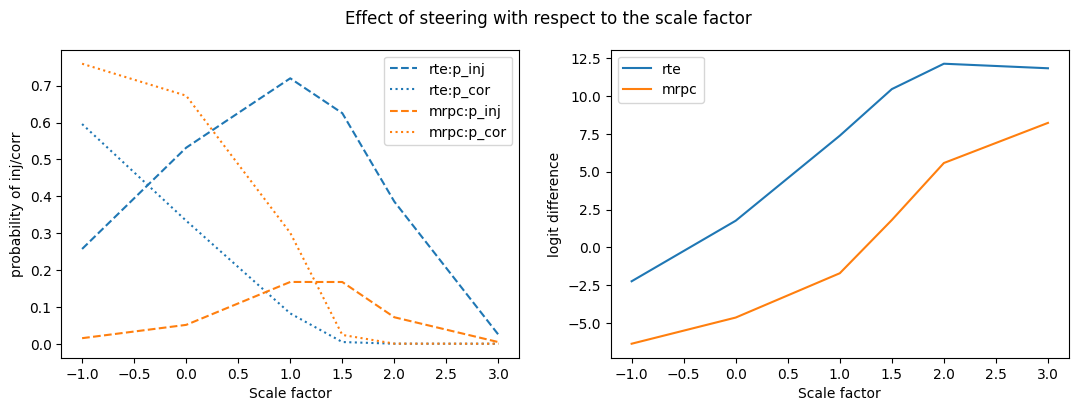

{'rte': {'asr': [0.3305462896823883,
   0.599033959209919,
   0.8189164996147156,
   0.8104405105113983,
   0.6927513182163239,
   0.5122519265860319],
  'ld': [-2.2405128479003906,
   1.7621005773544312,
   7.381558895111084,
   10.459957122802734,
   12.137068748474121,
   11.837055206298828],
  'mean_p_inj': [0.25705546140670776,
   0.5317912697792053,
   0.7200434803962708,
   0.625476598739624,
   0.38554632663726807,
   0.024504005908966064],
  'mean_p_cor': [0.5959628820419312,
   0.33372336626052856,
   0.08221054077148438,
   0.004595589824020863,
   4.370948227006011e-05,
   1.527044020122048e-07]},
 'mrpc': {'asr': [0.1277083158493042,
   0.1891116499900818,
   0.43340733647346497,
   0.5717564448714256,
   0.5357867740094662,
   0.5022067541722208],
  'ld': [-6.368443489074707,
   -4.638591766357422,
   -1.7101080417633057,
   1.808186650276184,
   5.575345039367676,
   8.226572036743164],
  'mean_p_inj': [0.015020395629107952,
   0.05114304646849632,
   0.16757991909980774

In [75]:
LAYER = 26
coefs = [-1, 0, 1, 1.5, 2, 3]

steering.cross_steering_coef(model, prompts, task_residuals, TRAIN_TASKS, TEST_TASKS, LAYER, coefs)

## On combine

Computing steering vector...
Computing steering effect for:
rte  ...


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [01:45<00:00, 21.07s/it]


mrpc  ...


100%|██████████| 5/5 [02:10<00:00, 26.20s/it]


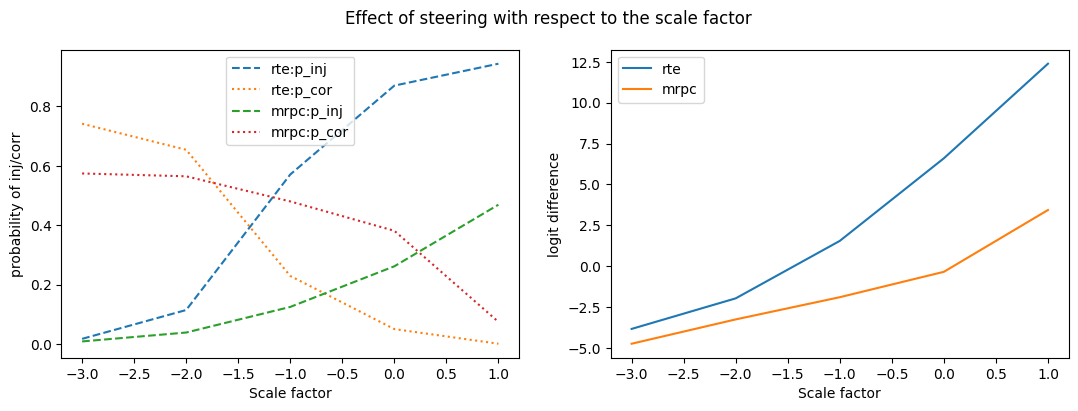

{'rte': {'asr': [0.13801193237304688,
   0.23035648465156555,
   0.6706998199224472,
   0.9097026586532593,
   0.971161812543869],
  'ld': [-3.825942039489746,
   -1.9585256576538086,
   1.552636742591858,
   6.600001335144043,
   12.378061294555664],
  'mean_p_inj': [0.017409440129995346,
   0.11445185542106628,
   0.5705881714820862,
   0.8696457743644714,
   0.9433253407478333],
  'mean_p_cor': [0.7413855195045471,
   0.6537388563156128,
   0.22918850183486938,
   0.05024042725563049,
   0.001001702155917883]},
 'mrpc': {'asr': [0.21734493970870972,
   0.23711517453193665,
   0.32246577739715576,
   0.44024698436260223,
   0.6971485018730164],
  'ld': [-4.731168746948242,
   -3.245530366897583,
   -1.8885815143585205,
   -0.3373824656009674,
   3.438516616821289],
  'mean_p_inj': [0.008689383044838905,
   0.038675881922245026,
   0.12485320121049881,
   0.2615984380245209,
   0.4688909649848938],
  'mean_p_cor': [0.5739994645118713,
   0.5644454956054688,
   0.4799216389656067,
   0

In [69]:
LAYER = 26
coefs = [-3, -2, -1, 0, 1]

steering.cross_steering_cb(model, prompts, task_residuals, TRAIN_TASKS, TEST_TASKS, LAYER, coefs)

# Steering at instruction